<a href="https://colab.research.google.com/github/rlagosb/GastricCancerIncidence/blob/main/4_Incidence_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction
This notebook analyzes gastric cancer incidence, building upon estimations from a previous notebook. It leverages population data and health coverage information across various provinces and regions. The primary goals are to identify incidence patterns, create provincial clusters based on risk and sociodemographic characteristics, and model incidence over time. The methods employed include:

1.  **Data Loading and Preparation:** This involves loading and processing incidence data, WHO standard population data, and Chile's political-administrative division.
2.  **Provincial Clustering:** K-Means clustering will be applied to group provinces into risk clusters (low, medium, high, and very high) based on incidence.
3.  **Time Series Analysis:** Temporal trends in incidence, stratified by sex, age, and risk clusters, will be analyzed.
4.  **Mixed Models:** Linear mixed-effects models will be fitted to assess the impact of covariates such as age, sex, rurality, and health coverage on incidence, accounting for variability across provinces.
5.  **Cartographic Visualizations:** Heatmaps will be generated to visualize incidence, rurality, and 'Isapre' (private health insurance) coverage by macro-region and over different time periods.

# Setup

In [1]:
# Importar librerías
import pandas as pd
import geopandas as gpd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, mannwhitneyu, norm, t, skewnorm, kstest
import requests
import io

# Carpetas de origen y destino
path_data='https://raw.githubusercontent.com/rlagosb/GastricCancerIncidence/main/Data/'
path_output = '/content/output/'

# Nro de habitantes para calcular tasas
HABS = 100000

## Cargar datos

In [3]:
# Function to download and read parquet from URL
def read_parquet_from_url(url):
    response = requests.get(url)
    response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
    return gpd.read_parquet(io.BytesIO(response.content))

prov_gpd = read_parquet_from_url(path_data + 'MAP_PROVINCIAS.parquet')

cubo = pd.read_parquet(path_data + 'CUBO_CANCER_DIGESTIVO.parquet')[lambda x: x.Provincia!=122] # filtrar provincia Antártica=122
cubo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24156 entries, 0 to 24947
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Provincia             24156 non-null  int64  
 1   Nombre Provincia      24156 non-null  object 
 2   Nombre Region         24156 non-null  object 
 3   Region                24156 non-null  int64  
 4   Macrorregion          24156 non-null  object 
 5   Año                   24156 non-null  int64  
 6   Sexo                  24156 non-null  object 
 7   RangoEdad10           24156 non-null  object 
 8   RangoEdad4080         24156 non-null  object 
 9   MedianaRangoEdad10    24156 non-null  float64
 10  MedianaRangoEdad4080  24156 non-null  float64
 11  Poblacion             24156 non-null  int64  
 12  PoblacionRural        24156 non-null  int64  
 13  A                     24156 non-null  int64  
 14  B                     24156 non-null  int64  
 15  C                     24

In [4]:
# Población OMS
# Fuente: https://seer.cancer.gov/stdpopulations/world.who.html
poblacion_estandar = (pd.read_excel(path_data + 'Parametros_estimaciones.xlsx', sheet_name='Poblacion_OMS').drop(columns=['Age']).
                      pivot_table(index=['RangoEdad4080'], values='PoblacionOMS', aggfunc='sum', margins=True).reset_index())
print(poblacion_estandar)

# Cargar Periodos
periodos_xl = pd.read_excel(path_data + 'Parametros_estimaciones.xlsx', sheet_name='Periodos RPC', header=1)
def cargar_periodos_rpc(df):
  df = (df.rename(columns={'ID':'Año'}).
        melt(id_vars='Año', value_name='Periodo', var_name='Provincia').
        dropna(subset='Periodo'))
  for col in df.columns: df[col] = df[col].astype(int)
  return df
periodos = cargar_periodos_rpc(periodos_xl)
periodos

# Mostrar periodos (Provincia 1000 es para estimaciones nacionales, el resto para calibración)
periodos.pivot(index='Año', columns='Provincia', values='Periodo').astype('Int64').fillna(0)

  RangoEdad4080  PoblacionOMS
0       [0, 40)        655070
1      [40, 50)        126256
2      [50, 60)         99165
3      [60, 70)         66777
4      [70, 80)         37287
5     [80, 120)         15445
6           All       1000000


Provincia,21,22,23,71,72,73,74,81,83,141,142,151,1000
Año,,,,,,,,,,,,,
2003,2005,2005,2005,0,0,0,0,0,2004,2004,2004,0,2004
2004,2005,2005,2005,0,0,0,0,0,2004,2004,2004,0,2004
2005,2005,2005,2005,0,0,0,0,0,2004,2004,2004,0,2004
2006,2005,2005,2005,0,0,0,0,2007,2007,2007,2007,0,2007
2007,2008,2008,2008,0,0,0,0,2007,2007,2007,2007,0,2007
2008,2008,2008,2008,0,0,0,0,2007,2007,2007,2007,2010,2007
2009,2008,2008,2008,0,0,0,0,2010,2010,2010,2010,2010,2011
2010,2011,2011,2011,0,0,0,0,2010,2010,2010,2010,2010,2011
2011,2011,2011,2011,0,0,0,0,2010,2010,2010,2010,2010,2011


## Funciones

In [5]:
#@title Cargar Estimaciones

def cargar_predicciones(**kwargs):
  predicciones = pd.read_parquet(path_data + 'Predicciones.parquet')

  # filtra predicciones por variables que se pasan en kwargs (ejemplo: Metodo=RIMcl)
  for variable, valor in kwargs.items():
    try:
      filtro = (predicciones[variable]==valor)
      predicciones = predicciones[filtro]
    except: print('No se encontró parámetro: '+variable)
  return predicciones

# Predicciones para Chile
inc = pd.concat([cargar_predicciones(Escenario='Chile', Grupo='Testing', Metodo='RIMclHombres'),
                 cargar_predicciones(Escenario='Chile', Grupo='Testing', Metodo='RIMclMujeres')])
print(inc.info())
inc.sample(3)

<class 'pandas.core.frame.DataFrame'>
Index: 5040 entries, 0 to 5459
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   RangoEdad4080     5040 non-null   object 
 1   Nombre Provincia  5040 non-null   object 
 2   Provincia         5040 non-null   int32  
 3   Sexo              5040 non-null   object 
 4   Periodo           5040 non-null   int32  
 5   Categoria         5040 non-null   object 
 6   Ratio             5040 non-null   object 
 7   RatioEst          5040 non-null   float64
 8   IncidenciaObs     5040 non-null   float64
 9   IncidenciaEst     5040 non-null   float64
 10  Poblacion         5040 non-null   int32  
 11  Metodo            5040 non-null   object 
 12  Escenario         5040 non-null   object 
 13  Grupo             5040 non-null   object 
 14  CasosEst          5040 non-null   float64
dtypes: float64(4), int32(3), object(8)
memory usage: 570.9+ KB
None


,RangoEdad4080,Nombre Provincia,Provincia,Sexo,Periodo,Categoria,Ratio,RatioEst,IncidenciaObs,IncidenciaEst,Poblacion,Metodo,Escenario,Grupo,CasosEst
4150,"[60, 70)",Itata,162,Mujer,2004,C16,RIM,0.739754,0.0,38.667051,6992,RIMclMujeres,Chile,Testing,2.703600
3412,"[40, 50)",Cachapoal,61,Mujer,2014,C16,RIM,0.569100,0.0,10.127871,138798,RIMclMujeres,Chile,Testing,14.057282
5088,"[80, 120)",San Felipe,57,Mujer,2007,C16,RIM,1.026742,0.0,110.175894,5304,RIMclMujeres,Chile,Testing,5.843729


In [6]:
#@title Calcular incidencia provincias

def calcular_incidencia_provincias(dataInc, niveles=None):

  # calcular casos
  dataInc['Casos'] = dataInc.IncidenciaEst * dataInc.Poblacion / HABS

  # agregar casos al nivel definido
  niveles += ['Periodo']
  dataInc = (dataInc.groupby(niveles)[['Casos','Poblacion']].sum())

  # calcular incidencia
  dataInc['IncidenciaEst'] = dataInc.Casos / dataInc.Poblacion * HABS

  return dataInc.reset_index()

calcular_incidencia_provincias(inc.copy(), niveles=['Metodo','Sexo']).\
pivot(index='Periodo', columns=['Metodo','Sexo'], values='IncidenciaEst').tail(5)

Metodo,RIMclHombres,RIMclMujeres
Sexo,Hombre,Mujer
Periodo,,
2011,31.301609,15.743266
2014,29.827147,15.131277
2017,28.276456,14.103975
2020,25.490528,12.916610
2023,24.250198,12.617167


Shapiro-Wilk Test Statistic : 0.974, p-value: 0.550
Kolmogorov-Smirnov Test Statistic : 0.105, p-value: 0.795
Normal distribution fit: mu = 0.534, std = 2.880


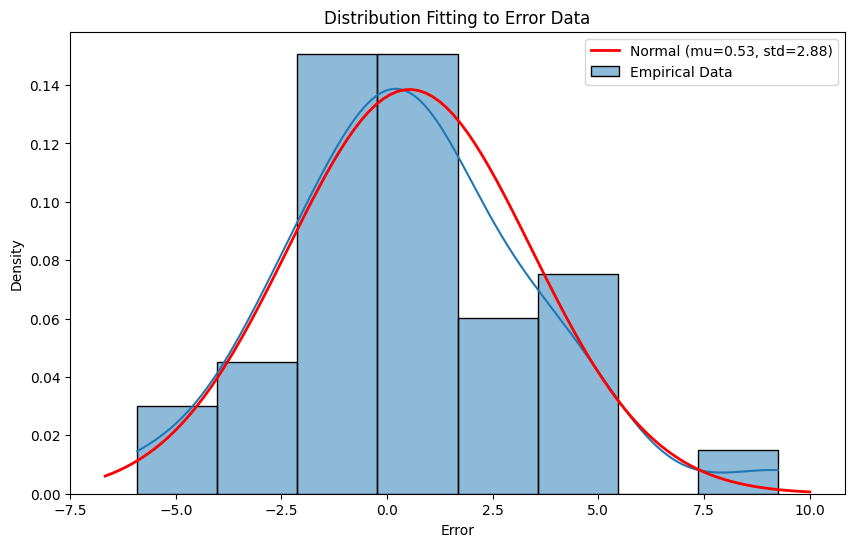

In [7]:
#@title Cálculo Errores

def cargar_errores_incidencia_periodos():

  # Cargar errores de la VALIDACIÓN CRUZADA (not Escenario1) (por eso los valores son diferentes al ejemplo del notebook 2)
  inc = cargar_predicciones(Metodo='RIM', Grupo='Testing')[lambda x: ~x.Escenario.isin(['Escenario1','Chile'])]
  inc['CasosEst'] = inc.IncidenciaEst * inc.Poblacion / HABS
  inc['CasosObs'] = inc.IncidenciaObs * inc.Poblacion / HABS

  # Evaluar normalidad de error provincial
  inc = inc.groupby(['Provincia','Periodo'])[['CasosEst','CasosObs','Poblacion']].sum().reset_index()
  inc['IncidenciaEst'] = inc.CasosEst / inc.Poblacion * HABS
  inc['IncidenciaObs'] = inc.CasosObs / inc.Poblacion * HABS
  inc['Error'] = (inc.IncidenciaEst - inc.IncidenciaObs)
  # Perform Shapiro-Wilk test for normality
  stat_shapiro, p_value_shapiro = shapiro(inc['Error'])
  print(f'Shapiro-Wilk Test Statistic : {stat_shapiro:.3f}, p-value: {p_value_shapiro:.3f}')

  # Perform Kolmogorov-Smirnov test for normality
  stat_kstest, p_value_kstest = kstest(inc['Error'], 'norm', args=(inc['Error'].mean(), inc['Error'].std()))
  print(f'Kolmogorov-Smirnov Test Statistic : {stat_kstest:.3f}, p-value: {p_value_kstest:.3f}')

  # Fit Normal distribution
  mu, std = norm.fit(inc['Error'])
  print(f"Normal distribution fit: mu = {mu:.3f}, std = {std:.3f}")

  # Visualize the fitted distributions
  plt.figure(figsize=(10, 6))
  sns.histplot(inc['Error'], kde=True, stat="density", label="Empirical Data")

  xmin, xmax = plt.xlim()
  x = np.linspace(xmin, xmax, 100)

  p_norm = norm.pdf(x, mu, std)
  plt.plot(x, p_norm, 'r', linewidth=2, label=f'Normal (mu={mu:.2f}, std={std:.2f})')

  plt.title("Distribution Fitting to Error Data")
  plt.xlabel("Error")
  plt.ylabel("Density")
  plt.legend()
  plt.show()

  return std

normal_std_error = cargar_errores_incidencia_periodos()

# Clusters de Incidencia
Generate three clusters of Provincias using k-means on the coverage data from the `clusters_cobertura_Fonasa` function

In [8]:
# Prepare data for clustering

def data_clusters_cobertura_Fonasa():
  tramos = ['A','B','C','D','Isapre']
  df = cubo.groupby(['Provincia','Nombre Provincia','Año'])[tramos+['Poblacion','PoblacionRural']].sum().reset_index()
  for col in tramos:
    df['cob'+col] = df[col] / df.Poblacion * 100
  df['Ruralidad'] = df.PoblacionRural / df.Poblacion * 100
  # Cobertura promedio por provincia
  df = df.groupby(['Provincia','Nombre Provincia'])[['cob'+col for col in tramos]+['Ruralidad']].mean().reset_index()

  # Calculate average incidence per province
  average_incidence_province = calcular_incidencia_provincias(inc, niveles=['Provincia']).groupby('Provincia')['IncidenciaEst'].mean().reset_index()
  # Merge with cobertura_df
  df = df.merge(average_incidence_province, on='Provincia', how='left')

  return df


cobertura_df = data_clusters_cobertura_Fonasa()

In [9]:
# Apply K-Means clustering to the scaled data

def generar_clusters(clustering_data, n_clusters=3, factor_incidencia=None, print_summary=True):

  # scale the data for clustering
  from sklearn.preprocessing import StandardScaler
  scaler = StandardScaler()
  scaler.fit(clustering_data)
  scaled_data = scaler.transform(clustering_data)

  if factor_incidencia:
  # check if IncidenciaEst is the second column
    if clustering_data.columns[1] != 'IncidenciaEst':
      raise ValueError("The second column must be IncidenciaEst")
    # amplify scaled_data.IncidenciaEst by factor
    scaled_data[:,1] *= factor_incidencia

  kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
  kmeans.fit(scaled_data)
  # add the cluster labels to the original DataFrame
  clustering_data['ClusterId'] = kmeans.labels_

  # Error incidencias
  errorInc = clustering_data.groupby('ClusterId').Provincia.count().reset_index()
  errorInc['DeltaInc95'] = 1.96 * normal_std_error / np.sqrt(errorInc.Provincia * 22/3) # 22/3 trienios y n_provincias del cluster

  # mostrar clusters
  promedios = (clustering_data.groupby('ClusterId')[[col for col in clustering_data if col not in ['Provincia','ClusterId']]].mean(). # promedio por métrica
               merge(errorInc.drop(columns='Provincia'), on='ClusterId'). # agregar error de incidencia
               sort_values(by='IncidenciaEst'). # ordenar por incidencia promedio
               reset_index(drop=False).reset_index(drop=False, names='Cluster'))  # crear ID ordenados
  # Put IncidenciaEst 95% confidencia intervals in a touple
  promedios['DeltaInc95'] = promedios.apply(lambda x: ((x['IncidenciaEst'] - x['DeltaInc95']).round(1),
                                                       (x['IncidenciaEst'] + x['DeltaInc95']).round(1)), axis=1)

  if print_summary:
    print(promedios.drop(columns=['ClusterId','index']))

  return clustering_data[['Provincia','ClusterId']].merge(promedios,on='ClusterId').drop(columns=['ClusterId','index'])

# Generar clusters
clusters = generar_clusters(cobertura_df[['Provincia','IncidenciaEst']].copy(), n_clusters=4)
# Agregar nombres
clusters['nombreCluster'] = clusters.Cluster.map({0:'Bajo riesgo',1:'Riesgo medio',2:'Alto riesgo',3:'Muy Alto riesgo'})

   Cluster  IncidenciaEst    DeltaInc95
0        0      13.449015  (12.9, 14.0)
1        1      17.894517  (17.0, 18.7)
2        2      23.806521  (23.4, 24.2)
3        3      32.337617  (31.8, 32.9)


## 📊Tabla 4

Territorio de la macrozona sur, en superficie territorial, número de provincias y regiones, y población, expresada en n y % respecto al país

In [11]:
def tabla_resumen_clusters(clusters, incidencia):

  # Calcular casos 2024
  incidencia = incidencia[lambda x: ((x.Escenario=='Chile')&(x.Grupo=='Testing')&(x.Periodo==2023))]
  incidencia['Casos'] = incidencia.IncidenciaEst * incidencia.Poblacion / HABS / 3 # dividido por tres para anualizar casos del periodo

  df = (clusters.
        # Superficie en kilómetros cuadrados, redondeado a dos decimales
        merge(prov_gpd[['Provincia','Superficie']], on='Provincia', how='left').
        # Poblacion 2024
        merge(cubo[(cubo.Año==2024)&(cubo.Categoria=='C16')].
              groupby(['Provincia', 'Nombre Provincia', 'Nombre Region']).Poblacion.sum().reset_index(), on='Provincia').
        # Casos 2024
        merge(incidencia.groupby('Provincia').Casos.sum(), on='Provincia').
        rename(columns={'Poblacion': 'Poblacion 2024', 'Casos':'Casos 2024'}))

  df['Nombre Provincia'] = df['Nombre Provincia'] + ', '
  df['Nombre Region'] = df['Nombre Region'] + ', '

  df = df.pivot_table(index=['Cluster','nombreCluster','IncidenciaEst','DeltaInc95'],
                      aggfunc={'Superficie':'sum','Poblacion 2024':'sum','Casos 2024':'sum',
                               'Nombre Provincia':(lambda x: x.unique().sum()),
                               'Nombre Region':(lambda x: x.unique().sum())}).reset_index()

  df['PorcPoblacion'] = df['Poblacion 2024'] / df['Poblacion 2024'].sum() * 100
  df['PorcSuperficie'] = df['Superficie'] / df['Superficie'].sum() * 100
  df['PorcCasos'] = df['Casos 2024'] / df['Casos 2024'].sum() * 100
  print('Totales:\n',df[['Poblacion 2024','Casos 2024','Superficie']].sum())

  # Decimales
  for col in ['IncidenciaEst','PorcPoblacion','PorcSuperficie','PorcCasos']:
    df[col] = df[col].round(1)

  # Agrupar columnas
  df['Incidencia 2003_2024'] = df.apply(lambda row: f"{row['IncidenciaEst']:.1f} ({row['DeltaInc95'][0]:.1f}-{row['DeltaInc95'][1]:.1f})", axis=1)
  df['Poblacion 2024'] = df['Poblacion 2024'].astype(int).astype(str) + ' (' + df['PorcPoblacion'].astype(str) + '%)'
  df['Superficie'] = df['Superficie'].round(0).astype(int).astype(str) + ' (' + df['PorcSuperficie'].astype(str) + '%)'
  df['Casos 2024'] = df['Casos 2024'].astype(int).astype(str) + ' (' + df['PorcCasos'].astype(str) + '%)'
  df['Nombre Provincia'] = df['Nombre Provincia'].str[:-2]
  df['Nombre Region'] = df['Nombre Region'].str[:-2]
  df = df.drop(columns=['DeltaInc95','PorcPoblacion','PorcSuperficie','PorcCasos','IncidenciaEst'])

  return df.set_index('Cluster')

cluster_summary = tabla_resumen_clusters(clusters, inc.copy())
pd.set_option('display.max_colwidth', None)
display(cluster_summary)
pd.reset_option('display.max_colwidth')

Totales:
 Poblacion 2024    2.013422e+07
Casos 2024        3.672543e+03
Superficie        7.371130e+05
dtype: float64


,nombreCluster,Casos 2024,Nombre Provincia,Nombre Region,Poblacion 2024,Superficie,Incidencia 2003_2024
Cluster,,,,,,,
0,Bajo riesgo,550 (15.0%),"Iquique, Tamarugal, Antofagasta, El Loa, Tocopilla, Copiapó, Chañaral, Elqui, Isla de Pascua, Cordillera, Chacabuco, Maipo, Talagante, Arica, Parinacota","Tarapacá, Antofagasta, Atacama, Coquimbo, Valparaíso, Metropolitana de Santiago, Arica y Parinacota",4254527 (21.1%),269375 (36.5%),13.4 (12.9-14.0)
1,Riesgo medio,791 (21.5%),"Santiago Norte, Santiago Occidente, Santiago Central, Santiago Oriente, Santiago Sur, Santiago Sur Oriente",Metropolitana de Santiago,6170121 (30.6%),2031 (0.3%),17.9 (17.0-18.7)
2,Alto riesgo,1329 (36.2%),"Huasco, Choapa, Limarí, Valparaíso, Los Andes, Petorca, Quillota, San Antonio, San Felipe, Marga Marga, Cachapoal, Cardenal Caro, Colchagua, Talca, Concepción, Llanquihue, Chiloé, Palena, Coyhaique, Aysén, Capitán Prat, Magallanes, Tierra del Fuego, Última Esperanza, Melipilla","Atacama, Coquimbo, Valparaíso, Libertador General Bernardo O'Higgins, Maule, Biobío, Los Lagos, Aysén del General Carlos Ibáñez del Campo, Magallanes y de la Antártica Chilena, Metropolitana de Santiago",6172144 (30.7%),340587 (46.2%),23.8 (23.4-24.2)
3,Muy Alto riesgo,1001 (27.3%),"Cauquenes, Curicó, Linares, Arauco, Bíobío, Cautín, Malleco, Osorno, General Carrera, Valdivia, Ranco, Diguillín, Itata, Punilla","Maule, Biobío, La Araucanía, Los Lagos, Aysén del General Carlos Ibáñez del Campo, Los Ríos, Ñuble",3537426 (17.6%),125120 (17.0%),32.3 (31.8-32.9)


In [12]:
# Calculate relative differences
# The IncidenciaEst values are constant for all provinces within the same cluster, so we can take the first value
cluster_incidences = clusters.groupby('Cluster')['IncidenciaEst'].first().sort_index()

incidence_low_risk = cluster_incidences.loc[0]
incidence_medium_risk = cluster_incidences.loc[1]
incidence_high_risk = cluster_incidences.loc[2]
incidence_very_high_risk = cluster_incidences.loc[3]

relative_diff_medium_low = ((incidence_medium_risk - incidence_low_risk) / incidence_low_risk) * 100
relative_diff_high_low = ((incidence_high_risk - incidence_low_risk) / incidence_low_risk) * 100
relative_diff_very_high_low = ((incidence_very_high_risk - incidence_low_risk) / incidence_low_risk) * 100

print(f"Relative difference (Riesgo medio vs Bajo riesgo): {relative_diff_medium_low:.1f}%")
print(f"Relative difference (Alto riesgo vs Bajo riesgo): {relative_diff_high_low:.1f}%")
print(f"Relative difference (Muy Alto riesgo vs Bajo riesgo): {relative_diff_very_high_low:.1f}%")

Relative difference (Riesgo medio vs Bajo riesgo): 33.1%
Relative difference (Alto riesgo vs Bajo riesgo): 77.0%
Relative difference (Muy Alto riesgo vs Bajo riesgo): 140.4%


# Series de tiempo de Incidencia
Incidencia estandarizada por año, estratificada por sexo, status urbano/rural, cobertura Fonasa/Isapre. Metodología de estandarización de incidencia: https://www.cdc.gov/nchs/hus/sources-definitions/age-adjustment.htm.


In [14]:
def cubo_incidencia_provincias_estratificada(pobEstandar=True):

  # Cargar cubo y agregar periodos
  metrics = (cubo[cubo.Categoria=='C16'].
             merge(periodos[periodos.Provincia==1000][['Año','Periodo']], on='Año').
            # suma años-personas de población rural, Fonasa e Isapre
             groupby(['RangoEdad4080','Sexo','Provincia','Periodo','MedianaRangoEdad4080'])[['PoblacionRural','A','B','C','D','Isapre']].sum().reset_index())

  # A predicciones de incidencia agregar métricas y pob estandar
  df = (inc.copy().
        merge(poblacion_estandar, on='RangoEdad4080', how='left').
        merge(metrics, on=['Provincia','Sexo','RangoEdad4080','Periodo'], how='left').
        drop(columns=['Categoria','Ratio','RatioEst','Metodo','Escenario','Grupo','IncidenciaObs']))

  return df

incProvinciasEstratificada = cubo_incidencia_provincias_estratificada()
incProvinciasEstratificada

,RangoEdad4080,Nombre Provincia,Provincia,Sexo,Periodo,IncidenciaEst,Poblacion,CasosEst,Casos,PoblacionOMS,MedianaRangoEdad4080,PoblacionRural,A,B,C,D,Isapre
0,"[0, 40)",Iquique,11,Hombre,2004,0.000000,252600,0.000000,0.000000,655070,20.0,3105,36074,25087,28736,30336,108851
1,"[0, 40)",Tamarugal,14,Hombre,2004,0.000000,19639,0.000000,0.000000,655070,20.0,10907,4325,1722,1190,1892,2087
2,"[0, 40)",Antofagasta,21,Hombre,2004,0.587587,350440,2.059141,2.059141,655070,20.0,8391,40458,31157,33039,29971,193563
3,"[0, 40)",El Loa,22,Hombre,2004,1.271130,161993,2.059141,2.059141,655070,20.0,6059,14234,14051,16480,19416,122093
4,"[0, 40)",Tocopilla,23,Hombre,2004,0.000000,34584,0.000000,0.000000,655070,20.0,1236,1252,1461,1111,352,20742
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5035,"[80, 120)",Santiago Occidente,13110,Mujer,2023,111.558698,41033,45.775881,45.775881,15445,90.0,175,900,40175,2044,1519,695
5036,"[80, 120)",Santiago Central,13111,Mujer,2023,66.837812,68488,45.775881,45.775881,15445,90.0,147,1530,45025,4292,4319,3620
5037,"[80, 120)",Santiago Oriente,13112,Mujer,2023,56.007968,123466,69.150798,69.150798,15445,90.0,30,2331,65716,8792,13989,38731
5038,"[80, 120)",Santiago Sur,13113,Mujer,2023,100.217121,56367,56.489385,56.489385,15445,90.0,0,1211,43822,3118,2944,2048


In [15]:
def serie_temporal_estrato(estrato, pobEstandar=False):

  cuboInc = cubo_incidencia_provincias_estratificada(pobEstandar=pobEstandar)

  dimensiones = ['Provincia','Nombre Provincia','Periodo','Sexo'] # dimensiones comunes para todas las series
  metricas = ['Casos','Poblacion','PoblacionOMS']

  # Proyectar casos por provincia en población real
  cuboInc['Casos'] = cuboInc['IncidenciaEst']/HABS * cuboInc['Poblacion']

  # Agrupar al nivel del estrato
  match estrato:

    case 'RangoEdad4080':

      # Incidencia nacional: tasa cruda equivale a la estandarizada pues ambas están estratificadas por edad
      # Casos por sexo-edad a nivel nacional
      total = cuboInc.groupby(['Periodo','Sexo',estrato], observed=True)[['Casos','Poblacion']].sum().reset_index()
      # Incidencia por sexo-edad
      total['Incidencia'] = total.Casos / total.Poblacion * HABS

      # Incidencia por Provincia
      df = cuboInc.groupby(dimensiones+[estrato])[['Casos','Poblacion']].sum().reset_index()
      df['Incidencia'] = df.Casos / df.Poblacion * HABS

    case 'nombreCluster':

      # Agregar datos clusters
      df = (cuboInc.groupby(dimensiones+['RangoEdad4080'])[metricas].agg({'Casos':'sum','Poblacion':'sum','PoblacionOMS':'first'}).reset_index().
            merge(clusters, on='Provincia'))

      if pobEstandar:
        # Incidencia nacional
        # Casos por sexo-edad a nivel nacional
        total = df.groupby(['Periodo','Sexo','RangoEdad4080',estrato], observed=True).agg({'Casos':'sum','Poblacion':'sum','PoblacionOMS':'first'}).reset_index()
        # Incidencia cruda por cluster-sexo-edad
        total['Incidencia'] = total.Casos / total.Poblacion * HABS
        # Casos en población OMS
        total['Casos'] = total.PoblacionOMS * total.Incidencia / HABS
        # Agrupar casos OMS por cluster-sexo
        total = total.groupby(['Periodo','Sexo',estrato])[['Casos','PoblacionOMS']].sum().reset_index()
        # Incidencia estandar por cluster-sexo
        total['Incidencia'] = total.Casos / total.PoblacionOMS * HABS

        # Incidencia por provincia
        # Incidencia cruda por cluster-sexo-edad
        df['Incidencia'] = df.Casos / df.Poblacion * HABS
        # Casos por sexo-edad en poblacion OMS
        df['Casos'] = df.PoblacionOMS * df.Incidencia / HABS
        # Agrupar casos por cluster-sexo
        df = df.groupby(dimensiones+[estrato])[['Casos','PoblacionOMS']].sum().reset_index()
        # Incidencia estandar
        df['Incidencia'] = df.Casos / df.PoblacionOMS * HABS

      else:
        # Casos por sexo-edad a nivel nacional
        total = df.groupby(['Periodo','Sexo',estrato], observed=True).agg({'Casos':'sum','Poblacion':'sum'}).reset_index()
        # Incidencia cruda por cluster-sexo
        total['Incidencia'] = total.Casos / total.Poblacion * HABS

        # Incidencia por provincia
        # Agrupar casos por cluster-sexo
        df = df.groupby(dimensiones+[estrato])[['Casos','Poblacion']].sum().reset_index()
        # Incidencia cruda
        df['Incidencia'] = df.Casos / df.Poblacion * HABS

  total.insert(0,'Nombre Provincia','Nacional')
  df = pd.concat([df, total])

  # Ordenar clusters
  if estrato=='nombreCluster':
    df.sort_values(by=['Periodo','nombreCluster'],
                   key=lambda x: x.map({'Bajo riesgo':0,'Riesgo medio':1,'Alto riesgo':2,'Muy alto riesgo':3}),
                   inplace=True)

  return df

serie_temporal_estrato(estrato='nombreCluster', pobEstandar=True)

,Provincia,Nombre Provincia,Periodo,Sexo,nombreCluster,Casos,PoblacionOMS,Incidencia
0,11.0,Iquique,2004,Hombre,Bajo riesgo,331.079674,1000000,33.107967
1,11.0,Iquique,2004,Mujer,Bajo riesgo,120.034390,1000000,12.003439
2,11.0,Iquique,2007,Hombre,Bajo riesgo,236.358466,1000000,23.635847
3,11.0,Iquique,2007,Mujer,Bajo riesgo,145.065068,1000000,14.506507
4,11.0,Iquique,2011,Hombre,Bajo riesgo,313.903129,1000000,31.390313
...,...,...,...,...,...,...,...,...
38,NaN,Nacional,2017,Mujer,Muy Alto riesgo,126.595975,1000000,12.659597
42,NaN,Nacional,2020,Hombre,Muy Alto riesgo,273.121664,1000000,27.312166
46,NaN,Nacional,2020,Mujer,Muy Alto riesgo,106.301012,1000000,10.630101
50,NaN,Nacional,2023,Hombre,Muy Alto riesgo,243.756264,1000000,24.375626


Period   2004  2007  2011  2014  2017  2020  2023
Sex                                              
Females  14.2  12.5  12.2  11.0   9.7   8.5   7.9
Males    36.0  32.8  30.7  26.9  23.7  20.3  17.8


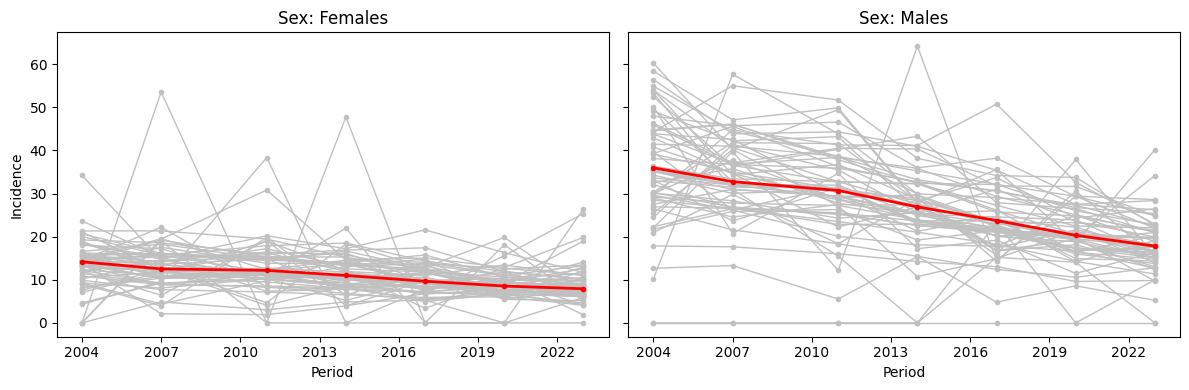

In [16]:
#@title 📈Fig 3a: Serie Sexo

def plot_serie_incidencia_sexo(pobEstandar=False, log_y=False):

  # Cargar datos
  data = (serie_temporal_estrato('RangoEdad4080', pobEstandar=pobEstandar).
          merge(poblacion_estandar, on='RangoEdad4080'))
  if pobEstandar:
    data['Casos'] = data.Incidencia/HABS * data.PoblacionOMS
    data['Poblacion'] = data.PoblacionOMS
  data = data.groupby(['Nombre Provincia','Periodo','Sexo'])[['Casos','Poblacion']].sum().reset_index()
  data['Incidencia'] = data.Casos / data.Poblacion * HABS
  data['Periodo'] = data.Periodo.astype(int)
  # Change to names in english
  data.rename(columns={'Sexo':'Sex','Periodo':'Period'}, inplace=True)
  data['Sex'] = data.Sex.map({'Hombre':'Males','Mujer':'Females'})

  print(data[data['Nombre Provincia']=='Nacional'].pivot(index=['Sex'], columns='Period', values='Incidencia').round(1))

  # anular log(0) para una visualización más limpia
  if log_y: data.loc[data.Incidencia==0,'Incidencia'] = pd.NA

  # Parámetros subplots
  unique_facets = ['Females','Males']
  unique_provs = data['Nombre Provincia'].unique()
  # drop Nacional and append to the end
  unique_provs = np.append(unique_provs[unique_provs!='Nacional'], 'Nacional')
  unique_provs = unique_provs
  n_cols = len(unique_facets)

  # Generar subplots
  fig, axes = plt.subplots(1, n_cols, squeeze=True, sharey=True, figsize=(n_cols*6, 4))

  for col_i, facet_value in enumerate(unique_facets):
      ax = axes[col_i]
      subset_data = data[data['Sex'] == facet_value]

      for prov in unique_provs:
          prov_data = subset_data[subset_data['Nombre Provincia'] == prov]
          ax.plot(prov_data['Period'].astype(int), prov_data['Incidencia'], marker='.',
                  color = ('red' if prov == 'Nacional' else 'silver'),
                  linewidth = (2 if prov == 'Nacional' else 1))

      ax.set_title(f'Sex: {facet_value}') # Add title for each subplot
      ax.set_xlabel('Period')
      ax.set_ylabel('Incidence')
      if log_y: ax.set_yscale('log')
      # Ensure x-axis labels are integers
      ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
      # Add Sexo label only for the first column
      ax.set_ylabel('Incidence' if col_i == 0 else '')

  plt.subplots_adjust(wspace=0.02, hspace=0.05)
  plt.tight_layout()

  plt.show()

plot_serie_incidencia_sexo(pobEstandar=True)

In [17]:
def plot_serie_incidencia(estrato, pobEstandar=False, log_y=False):

  # Cargar datos
  data = (serie_temporal_estrato(estrato, pobEstandar=pobEstandar).
  # English labels
          rename(columns={'Sexo':'Sex', 'Periodo':'Period'}))
  data['Sex'] = data.Sex.map({'Hombre':'Males','Mujer':'Females'})
  if estrato=='nombreCluster':
    data['nombreCluster'] = data.nombreCluster.map({'Bajo riesgo':'Low risk','Riesgo medio':'Medium risk','Alto riesgo':'High risk','Muy Alto riesgo':'Very High risk'})


  print(data[data['Nombre Provincia']=='Nacional'].pivot(index=['Sex',estrato], columns='Period', values='Incidencia').round(1))

  # anular log(0)
  if log_y: data.loc[data.Incidencia==0,'Incidencia'] = pd.NA

  # Parámetros subplots
  unique_facets = data[estrato].unique()
  unique_sexos = data['Sex'].unique()
  unique_provs = data['Nombre Provincia'].unique()
  # drop Nacional and append to the end
  unique_provs = np.append(unique_provs[unique_provs!='Nacional'], 'Nacional')
  unique_provs = unique_provs
  n_cols = len(unique_facets)
  n_rows = len(unique_sexos)

  # Generar subplots
  fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows * 3), squeeze=True, sharey=True)

  for row_i, sexo in enumerate(unique_sexos):
      for col_i, facet_value in enumerate(unique_facets):
          ax = axes[row_i, col_i]
          subset_data = data[(data[estrato] == facet_value) & (data.Sex == sexo)]

          for prov in unique_provs:
              prov_data = subset_data[subset_data['Nombre Provincia'] == prov]
              ax.plot(prov_data['Period'], prov_data['Incidencia'], marker='.',
                      color = ('red' if prov == 'Nacional' else 'silver'),
                      linewidth = (2 if prov == 'Nacional' else 1))

          # Add estrato title only for the first row
          if row_i == 0: ax.set_title(f'{facet_value}')
          # Remove x-axis tick labels for first row
          ax.tick_params(axis='x', which='both', labelbottom=(False if row_i==0 else True))
          # Add Sexo label only for the first column
          ax.set_ylabel(f'{sexo}' if col_i == 0 else '')

          if log_y: ax.set_yscale('log')
  plt.subplots_adjust(wspace=0.02, hspace=0.05)
  plt.tight_layout()

  plt.show()

Period                  2004   2007   2011   2014   2017   2020   2023
Sex     RangoEdad4080                                                 
Females [0, 40)          1.4    1.0    1.2    1.3    1.0    1.3    1.1
        [40, 50)         8.7    7.7    8.1    7.5    7.8    6.1    6.0
        [50, 60)        18.9   17.5   16.7   16.3   14.8   12.8   13.1
        [60, 70)        49.7   42.8   43.7   35.9   30.9   25.3   25.7
        [70, 80)       101.2   98.2   90.9   84.6   68.8   62.8   52.7
        [80, 120)      206.4  170.6  155.1  131.3  122.7  106.6   94.6
Males   [0, 40)          1.2    1.0    1.0    1.2    0.8    1.0    0.9
        [40, 50)        16.6   15.6   15.1   12.0   10.9    8.8    7.7
        [50, 60)        55.4   47.5   44.2   39.1   36.5   31.2   25.4
        [60, 70)       150.0  143.0  125.1  103.7   91.6   76.8   72.3
        [70, 80)       292.8  275.4  271.3  239.2  200.8  174.0  140.4
        [80, 120)      431.2  362.6  343.1  315.8  300.8  246.2  238.6


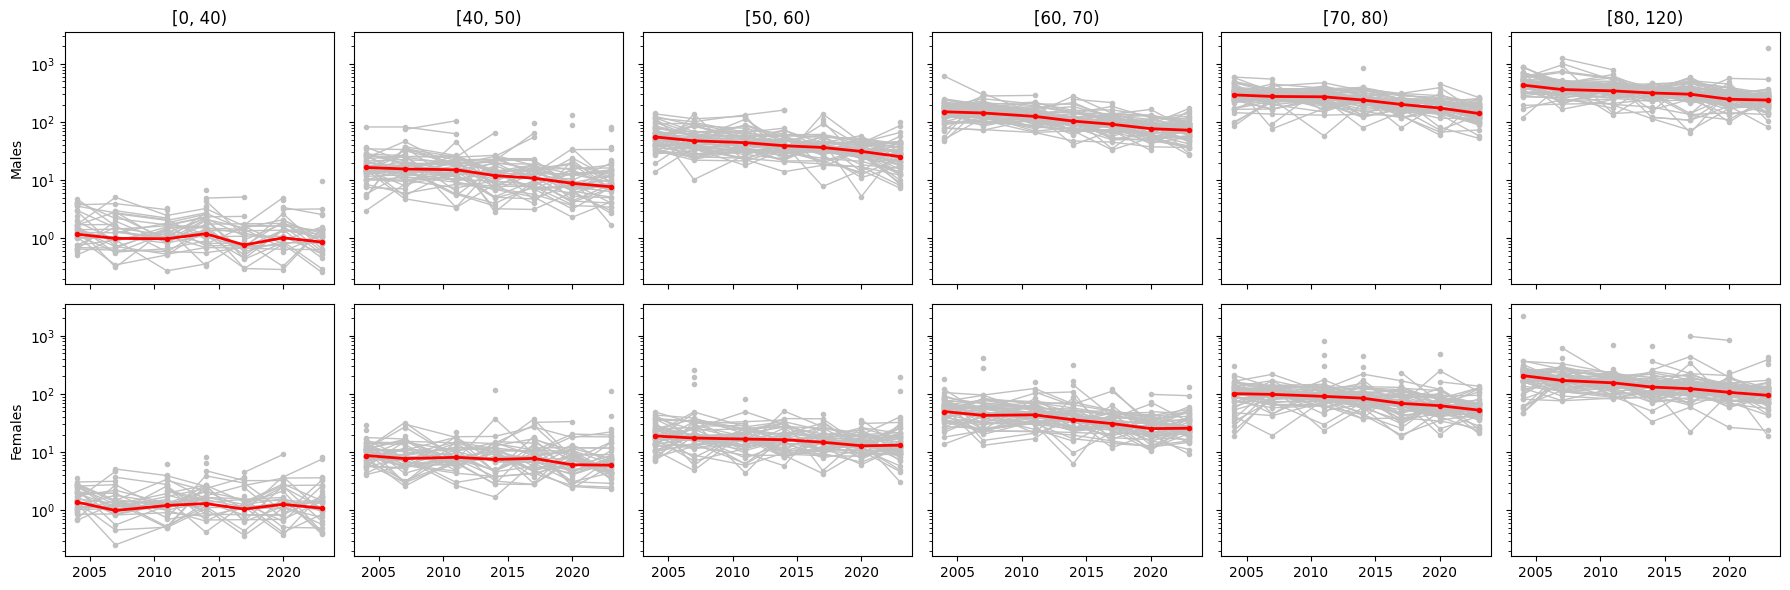

In [18]:
# @title 📈Fig 3b: Serie Sexo - Edad

# Incidencia cruda
plot_serie_incidencia(estrato='RangoEdad4080', pobEstandar=False, log_y=True)

Period                  2004  2007  2011  2014  2017  2020  2023
Sex     nombreCluster                                           
Females High risk       14.8  13.4  13.1  12.1  10.4   8.9   8.7
        Low risk        12.5  11.2  10.6   8.9   8.5   7.8   7.0
        Medium risk     12.2   9.9  10.1   8.8   7.6   7.3   5.9
        Very High risk  17.7  16.5  15.5  14.4  12.7  10.6  10.6
Males   High risk       37.9  33.3  31.3  28.3  24.4  21.8  19.0
        Low risk        30.6  28.0  25.7  23.7  21.0  18.1  16.0
        Medium risk     29.3  27.7  25.9  21.9  18.9  15.0  13.0
        Very High risk  46.2  42.7  40.5  34.2  31.6  27.3  24.4


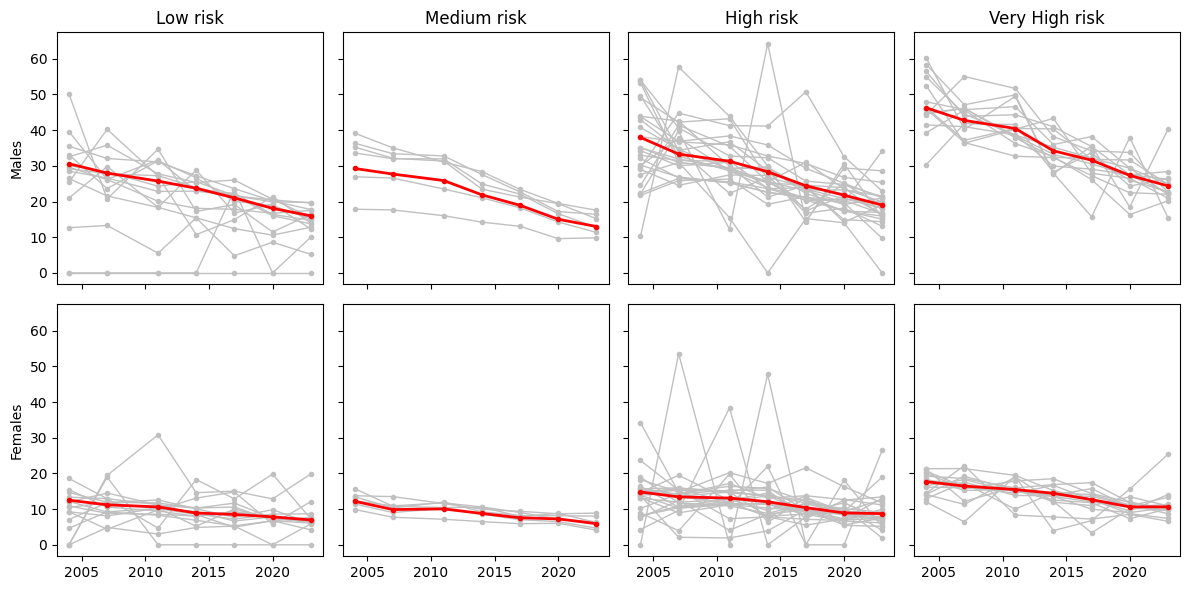

In [19]:
# @title 📈Fig 6: Serie Clusters
# Incidencia estandarizada
plot_serie_incidencia(estrato='nombreCluster', pobEstandar=True) #, log_y=True

Period                  2004  2007  2011  2014  2017  2020  2023
Sex     nombreCluster                                           
Females High risk       17.1  16.6  17.4  17.1  15.9  14.5  14.8
        Low risk        11.3  10.9  11.2  10.0  10.0   9.5   8.9
        Medium risk     14.9  13.0  13.9  13.0  11.6  10.9   9.6
        Very High risk  20.1  20.2  20.6  20.7  19.6  17.5  18.4
Males   High risk       34.8  33.1  34.0  33.6  31.4  30.1  28.8
        Low risk        21.9  21.6  21.6  21.6  20.4  18.2  17.3
        Medium risk     25.1  25.3  25.5  23.3  21.4  17.5  16.2
        Very High risk  44.6  44.4  46.0  42.6  42.8  39.9  38.9


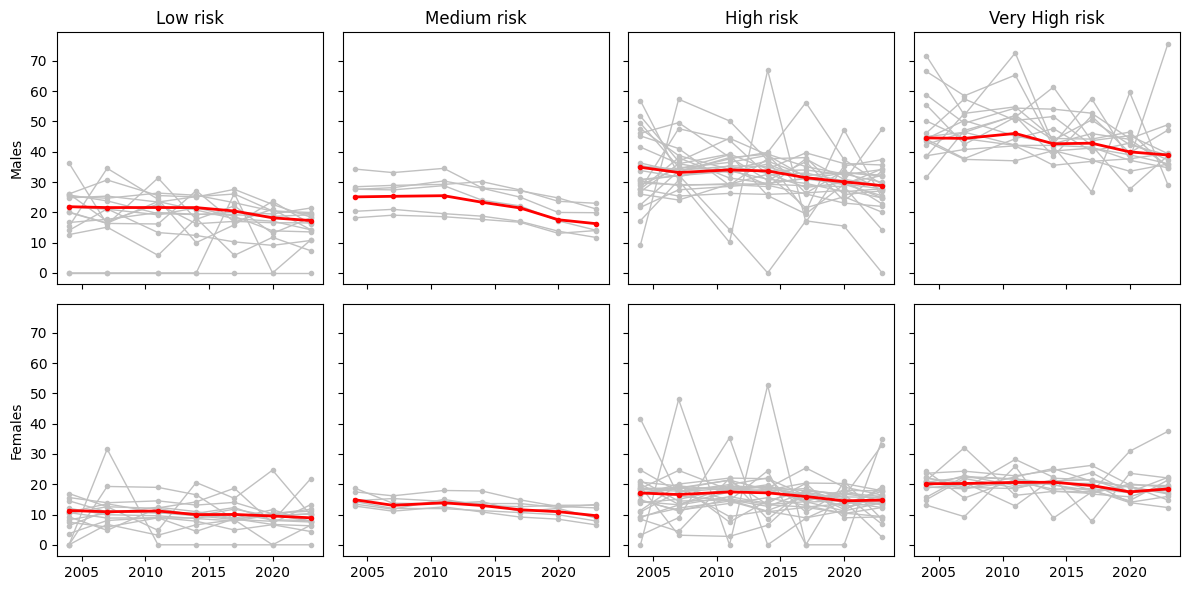

In [20]:
#@title 📈Material Sup 8
# Incidencia cruda
plot_serie_incidencia(estrato='nombreCluster', pobEstandar=False)

## Modelos Mixtos

In [21]:
#@title 📈Material Sup 6a: Modelo Sexo-Edad

def regresion_mixta_incidencia2(data):

  # Transformar outcome
  data=data[data.IncidenciaEst>0]
  data['LogIncidencia'] = np.log(data.IncidenciaEst)

  # Preparar Covariables
  data['RangoEdad4080'] = data['RangoEdad4080'].astype('category')
  data['SexoFemenino'] = (data['Sexo']=='Mujer').astype(int)
  data['SexoMasculino'] = (data['Sexo']=='Hombre').astype(int)
  data['Ruralidad'] = data.PoblacionRural/data.Poblacion
  for tramo in ['A','B','C','D','Isapre']:
    data['cob'+tramo] = data[tramo] / data.Poblacion

  # Define the mixed-effects model using statsmodels mixedlm
  mixed_model = smf.mixedlm("LogIncidencia ~ 1 + RangoEdad4080 + SexoMasculino + Periodo:SexoMasculino:RangoEdad4080 + Periodo:SexoFemenino:RangoEdad4080",
                            data,
                            groups='Provincia',
                            re_formula='1')

  # Fit the model
  mixed_results = mixed_model.fit()
  print(mixed_results.summary())
  return mixed_results

modelo2 = regresion_mixta_incidencia2(incProvinciasEstratificada.copy())

                          Mixed Linear Model Regression Results
Model:                       MixedLM           Dependent Variable:           LogIncidencia
No. Observations:            4128              Method:                       REML         
No. Groups:                  60                Scale:                        0.1948       
Min. group size:             1                 Log-Likelihood:               -2697.4320   
Max. group size:             84                Converged:                    Yes          
Mean group size:             68.8                                                         
------------------------------------------------------------------------------------------
                                               Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------
Intercept                                       8.068    6.816   1.184 0.237 -5.291 21.427
RangoEdad4080[T.[40, 50)] 

In [22]:
#@title 📈Material Sup 6b: Modelo Covariables

def regresion_mixta_incidencia(data):

  # Transformar outcome (log incidencia cruda)
  data=data[data.IncidenciaEst>0]
  data['LogIncidencia'] = np.log(data.IncidenciaEst)

  # Preparar Covariables
  data['Ruralidad'] = data.PoblacionRural/data.Poblacion * 100
  for tramo in ['A','B','C','D','Isapre']:
    data['cob'+tramo] = data[tramo] / data.Poblacion * 100
  data['RangoEdad4080'] = data['RangoEdad4080'].astype('category')
  data['SexoMasculino'] = (data['Sexo']=='Hombre').astype(int)

  # Define the mixed-effects model using statsmodels mixedlm
  mixed_model = smf.mixedlm("LogIncidencia ~ 1 + Periodo + SexoMasculino + RangoEdad4080 + Ruralidad + cobIsapre", #+ cobA + cobB + cobC + cobD
                            data,
                            groups='Provincia',
                            re_formula='1')

  # Fit the model
  mixed_results = mixed_model.fit()
  print(mixed_results.summary())
  return mixed_results

# modelo con incidencia cruda
modelo = regresion_mixta_incidencia(incProvinciasEstratificada.copy())

# Coeficientes exponenciados
(np.exp(modelo.params[['SexoMasculino',
                        'RangoEdad4080[T.[40, 50)]','RangoEdad4080[T.[50, 60)]','RangoEdad4080[T.[60, 70)]','RangoEdad4080[T.[70, 80)]','RangoEdad4080[T.[80, 120)]',
                        'Periodo',
                        'Ruralidad','cobIsapre']])-1).round(3)*100

                Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    LogIncidencia
No. Observations:      4128       Method:                REML         
No. Groups:            60         Scale:                 0.2317       
Min. group size:       1          Log-Likelihood:        -2978.5926   
Max. group size:       84         Converged:             Yes          
Mean group size:       68.8                                           
----------------------------------------------------------------------
                           Coef.  Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------------------------
Intercept                  57.517    2.503  22.977 0.000 52.611 62.424
RangoEdad4080[T.[40, 50)]   1.986    0.029  68.082 0.000  1.929  2.043
RangoEdad4080[T.[50, 60)]   2.830    0.029  97.373 0.000  2.773  2.887
RangoEdad4080[T.[60, 70)]   3.680    0.030 123.361 0.000  3.621  3.738
RangoEdad4080[T.[70, 80

,0
SexoMasculino,108.7
"RangoEdad4080[T.[40, 50)]",628.8
"RangoEdad4080[T.[50, 60)]",1595.0
"RangoEdad4080[T.[60, 70)]",3862.9
"RangoEdad4080[T.[70, 80)]",7809.9
"RangoEdad4080[T.[80, 120)]",12277.0
Periodo,-2.8
Ruralidad,0.6
cobIsapre,-1.1


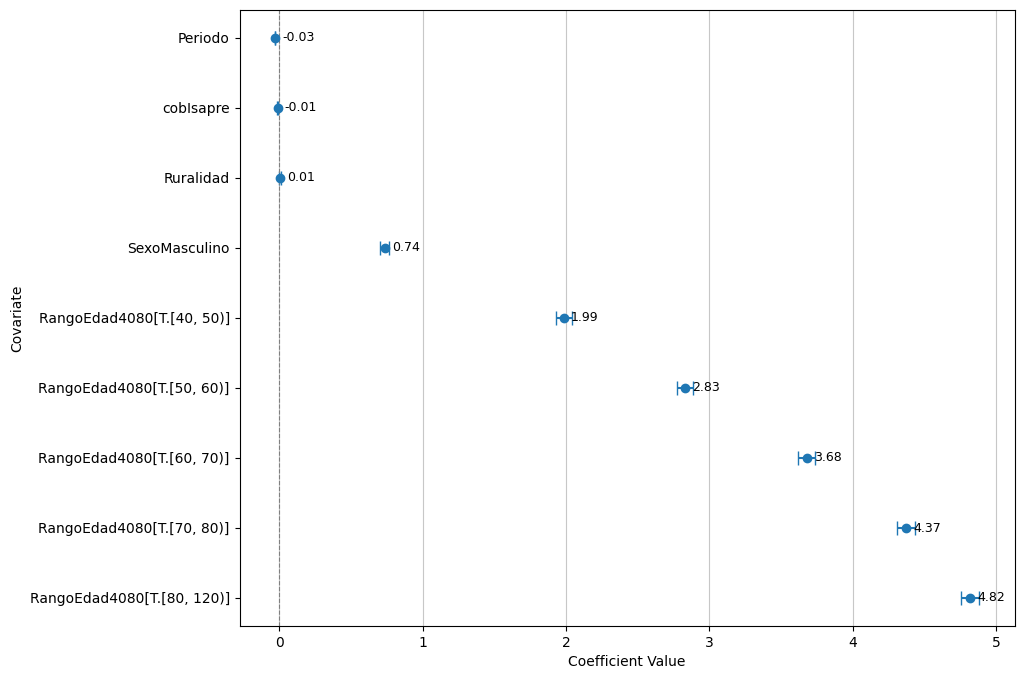

In [23]:
#@title 📈Fig 4: Forest plots
# showing the effect sizes of covariates

def forest_plot(modelo, parametros, logScale=False, exponentiated=False):

  # Extract coefficients and standard errors from the model
  coefs = modelo.params[parametros]
  conf_int = modelo.conf_int().loc[coefs.index]

  # Create a DataFrame for plotting
  plot_data = pd.DataFrame({'Coefficient': coefs.values,
                            'Lower CI': conf_int[0].values,
                            'Upper CI': conf_int[1].values,
                            'Coefficient_Index': coefs.index}) # Store index for plotting

  # Sort data by percentage change for better visualization
  plot_data = plot_data.sort_values(by='Coefficient', ascending=False)

  # Create the forest plot
  plt.figure(figsize=(10, 8))
  plt.errorbar(plot_data['Coefficient'],
               plot_data['Coefficient_Index'],
               xerr=[plot_data['Coefficient'] - plot_data['Lower CI'], plot_data['Upper CI'] - plot_data['Coefficient']],
               fmt='o', capsize=5)

  # Formatear plot
  plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
  # Add text annotations
  for i, row in plot_data.iterrows():
      plt.text(row['Coefficient'] + 0.05, row['Coefficient_Index'], f'{row["Coefficient"]:.2f}', ha='left', va='center', fontsize=9) # Annotate with actual coefficient values
  # Update axis labels
  plt.xlabel('Coefficient Value')
  plt.ylabel('Covariate')
  plt.grid(axis='x', alpha=0.7)
  if logScale: plt.xscale('symlog') # Set x-axis to symmetric log scale
  plt.show()

forest_plot(modelo, ['SexoMasculino',
                      'RangoEdad4080[T.[40, 50)]', 'RangoEdad4080[T.[50, 60)]','RangoEdad4080[T.[60, 70)]', 'RangoEdad4080[T.[70, 80)]','RangoEdad4080[T.[80, 120)]',
                      'Periodo', #'Pandemia2020','cobA','cobB', 'cobC','cobD',
                      'Ruralidad','cobIsapre'],
            logScale=False)

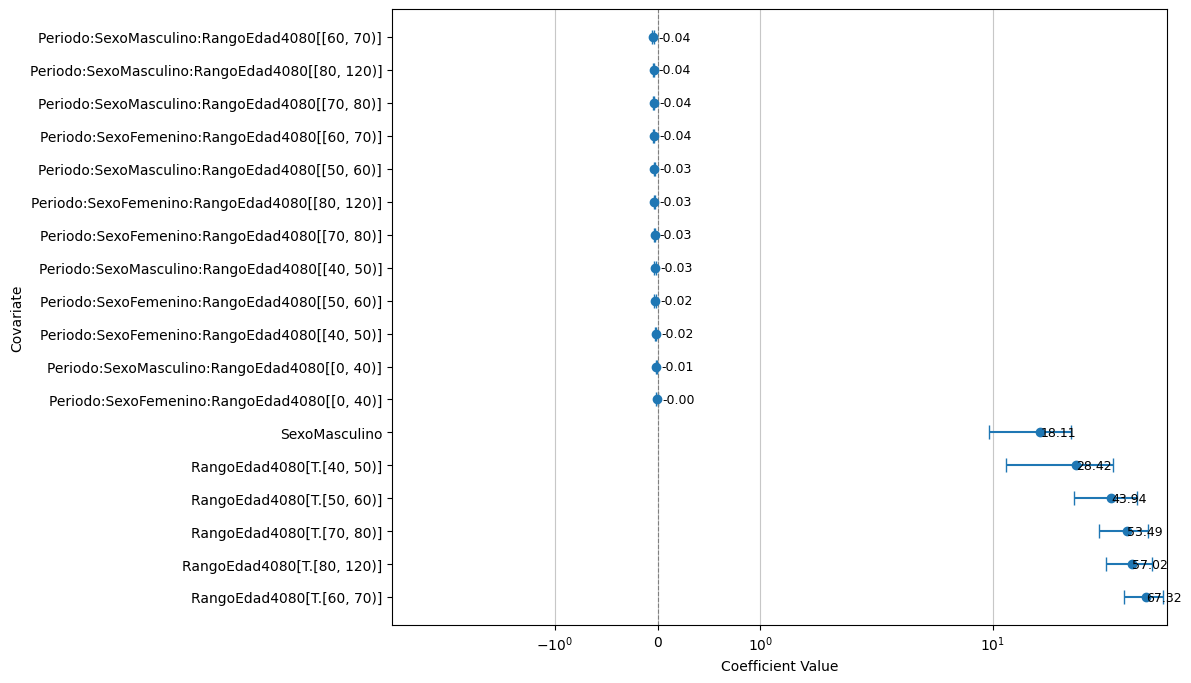

In [24]:
forest_plot(modelo2,
            [p for p in modelo2.params.index if p not in ['Intercept','Provincia Var']],
            logScale=True)

# Mapas de incidencia

In [25]:
def agregar_dimensiones_mapas(df_incidencia, cobertura):

  # Dimensiones (fijas en el tiempo)
  regiones = cubo[['Provincia','Nombre Provincia','Nombre Region']].drop_duplicates()
  ruralidad = cubo[cubo.Categoria=='C16'].groupby(['Provincia','Año'])[['Poblacion','PoblacionRural']].sum().reset_index()
  ruralidad['Ruralidad'] = ruralidad.PoblacionRural / ruralidad.Poblacion * 100
  ruralidad = ruralidad.groupby('Provincia')[['Ruralidad']].mean().reset_index()
  macrorregiones = (cubo[['Provincia','Macrorregion']].
                    drop_duplicates()[lambda x: ~((x.Provincia==62)&(x.Macrorregion=='Centro Norte'))].
                    replace({'Centro Norte':'Centro','Centro Sur':'Sur'}))
  macrorregiones.loc[macrorregiones.Provincia==52, 'Macrorregion'] = 'Isla de Pascua'

  # Agregar dimensiones
  df_incidencia = (df_incidencia.merge(ruralidad, on='Provincia').
                   merge(cobertura, on='Provincia').
                   merge(regiones, on='Provincia').
                   merge(macrorregiones, on='Provincia'))

  return df_incidencia

incMaps = calcular_incidencia_provincias(inc.copy(), niveles=['Provincia'])
incMaps = agregar_dimensiones_mapas(incMaps, cobertura_df[['Provincia','cobA','cobC','cobIsapre']])


In [26]:
def mapa_incidencia(data, provincias, colorDim='IncidenciaEst', colorScale='OrRd', vmax=None, subplot_col=None, nombres_provincias=False, grilla2x2=False):

    # Include Macrorregion in the merge for provincial level
    incProv = data.groupby(['Provincia','Nombre Provincia'])[colorDim].mean().reset_index()
    # Filtrar isla de pascua
    incProv = incProv[incProv.Provincia!=52]

    # Ensure Macrorregion2 is in the data before merging
    if subplot_col in data.columns:
        incProv = incProv.merge(data[['Provincia', subplot_col]].drop_duplicates(), on='Provincia', how='left')

    provincias = provincias.merge(incProv, on='Provincia')

    # Calculate vmax before the loop to ensure consistent color scale
    if vmax is None: vmax = provincias[colorDim].max()
    vmin = provincias[colorDim].min()

    if subplot_col:
        unique_subgroups =  ['Norte','Centro','Sur','Extremo Sur'] #provincias[subplot_col].unique()
        n_subgroups = len(unique_subgroups)
        n_cols = (2 if grilla2x2 else min(n_subgroups, 5))
        n_rows = (2 if grilla2x2 else (n_subgroups + n_cols - 1) // n_cols)

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 6))
        axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

        for i, subgroup in enumerate(unique_subgroups):
            ax = axes[i]
            subgroupProv =provincias[provincias[subplot_col] == subgroup]
            subgroupProv.plot(column=colorDim, cmap=colorScale, legend=False, edgecolor='silver', linewidth=0.3, vmax=vmax, vmin=vmin, ax=ax)
            ax.set_title(f'{subplot_col}: {subgroup}')
            ax.set_axis_off() # Turn off the axis

            # Add province names as text annotations
            if nombres_provincias:
              fix_position = ['Marga Marga','Chacabuco','Talagante','Maipo','Cordillera']
              labels_to_plot = subgroupProv[['Provincia','centroid_x','centroid_y','Nombre Provincia']][~subgroupProv.Provincia.isin([13109,13110,13111,13113,13114])]
              labels_to_plot.loc[labels_to_plot.Provincia==13112,'Nombre Provincia']='Santiago'
              for cod, x, y, label in labels_to_plot.itertuples(index=False):
                ax.text(x, y, label, fontsize=8, ha=('center' if label not in fix_position else 'left'), va='top')

        # Add a single colorbar for the entire figure
        cbar_ax = fig.add_axes([0.95, 0.15, 0.02, 0.7]) # [left, bottom, width, height]
        sm = plt.cm.ScalarMappable(cmap=colorScale, norm=plt.Normalize(vmin=vmin, vmax=vmax))
        sm._A = []
        fig.colorbar(sm, cax=cbar_ax, label=colorDim)

        plt.show()

    else:
        provincias.plot(column=colorDim, cmap=colorScale, legend=True, edgecolor='silver', linewidth=0.1, vmax=vmax)
        plt.show()

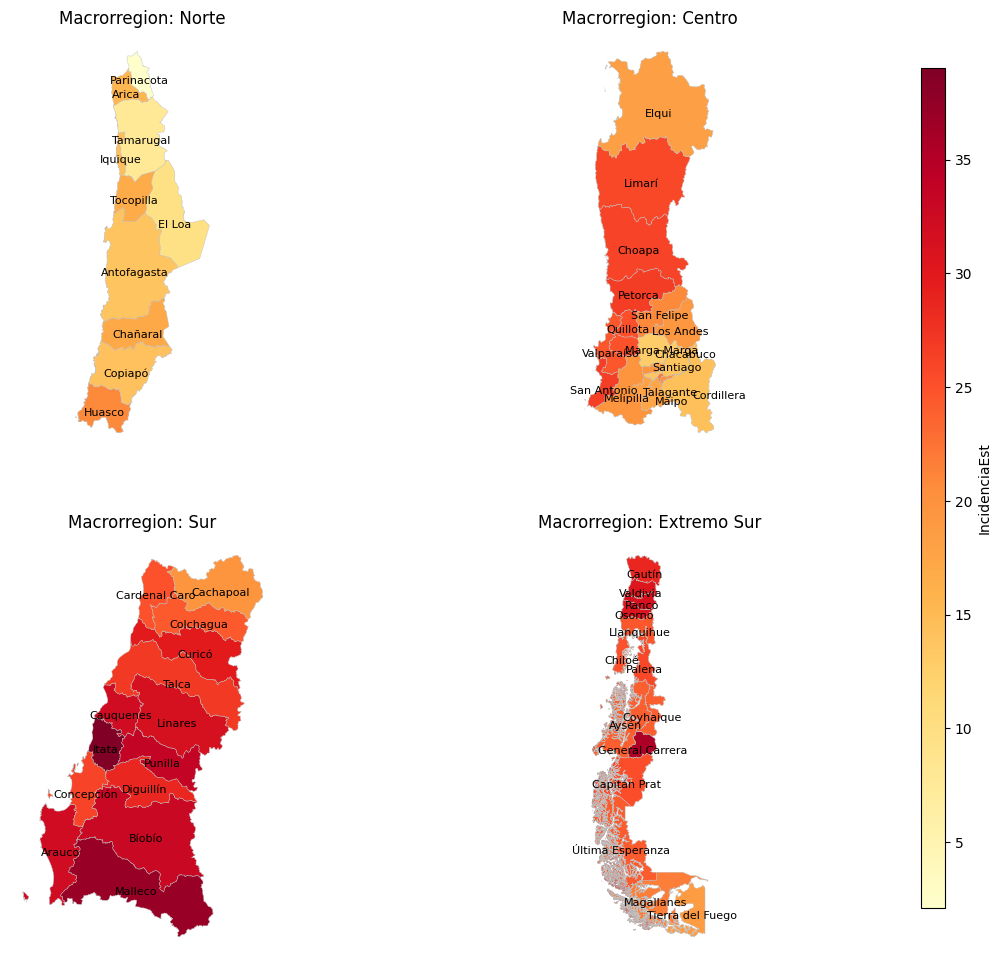

In [27]:
#@title 🌎Fig 2b: Heatmap Provincias
mapa_incidencia(incMaps, prov_gpd, colorDim='IncidenciaEst', colorScale='YlOrRd', subplot_col='Macrorregion', nombres_provincias=True, grilla2x2=True)

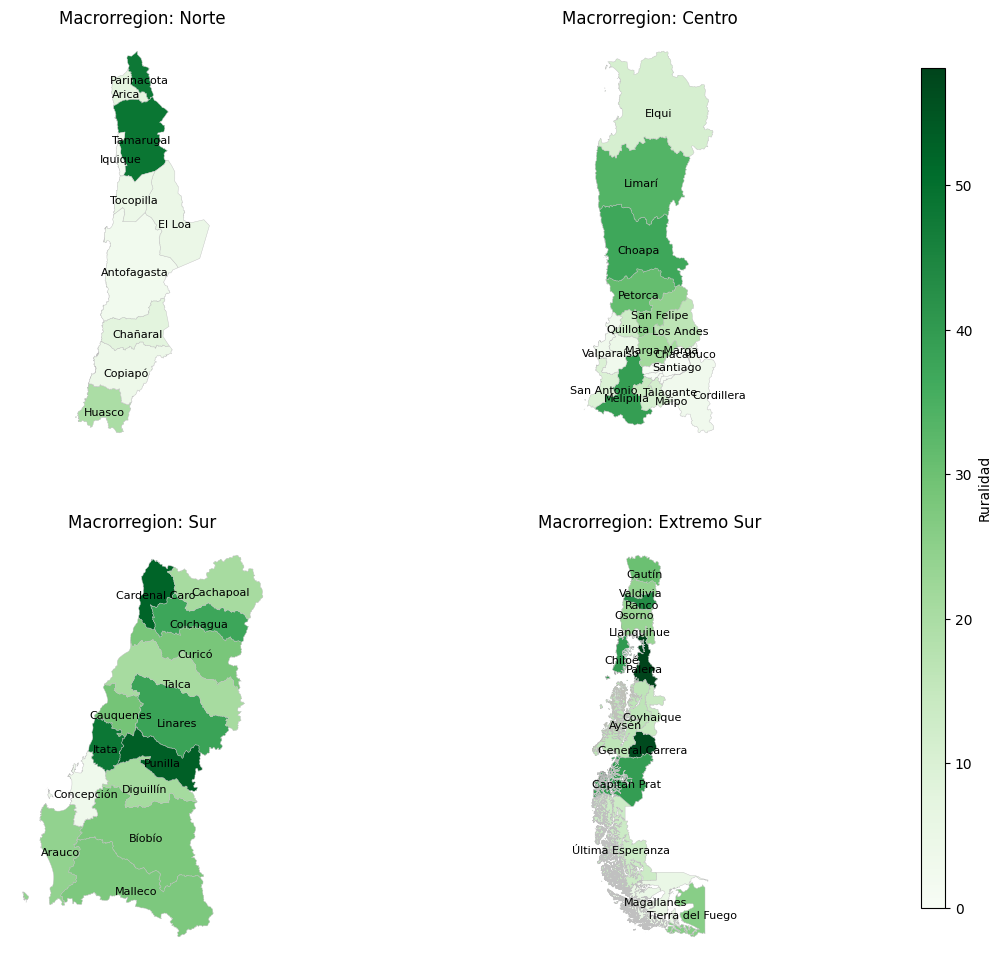

In [28]:
#@title 🌎Material Sup 7a
mapa_incidencia(incMaps, prov_gpd, colorDim='Ruralidad', colorScale='Greens', subplot_col='Macrorregion', nombres_provincias=True, grilla2x2=True)

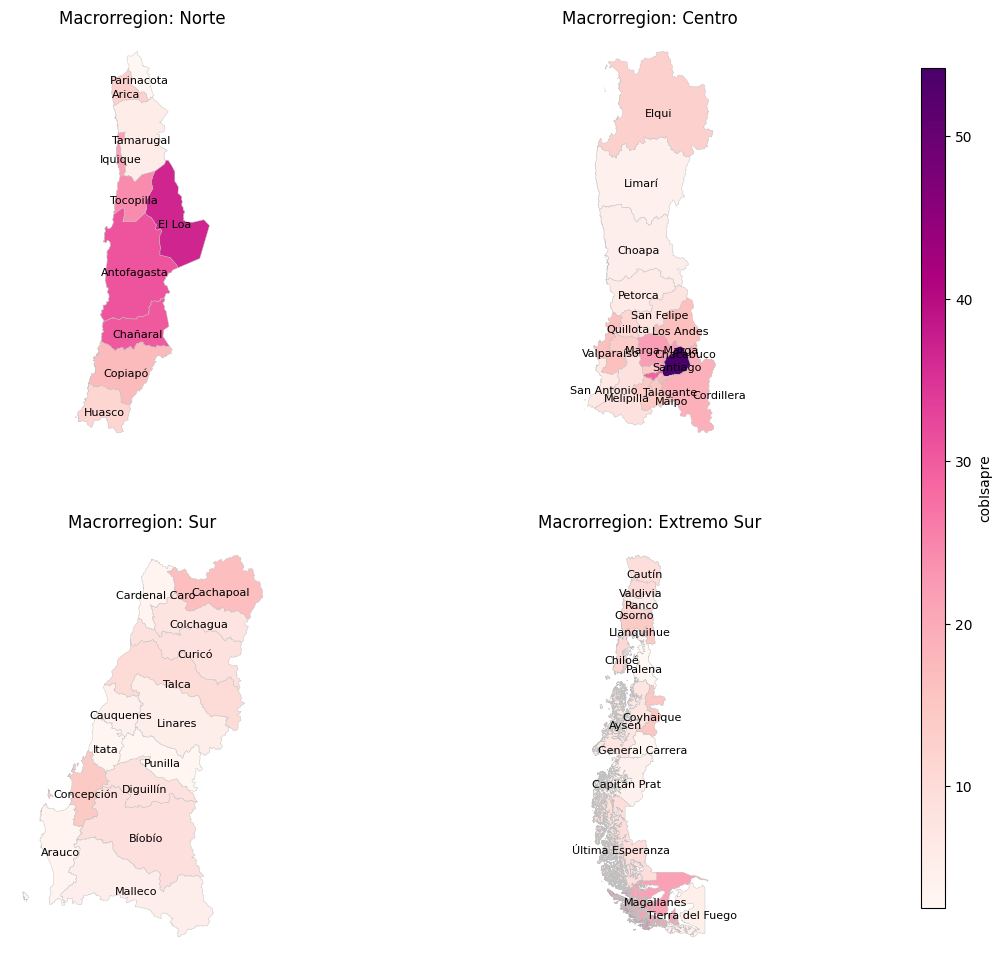

In [29]:
#@title 🌎Material Sup 7b
mapa_incidencia(incMaps, prov_gpd, colorDim='cobIsapre', colorScale='RdPu', subplot_col='Macrorregion', nombres_provincias=True, grilla2x2=True)

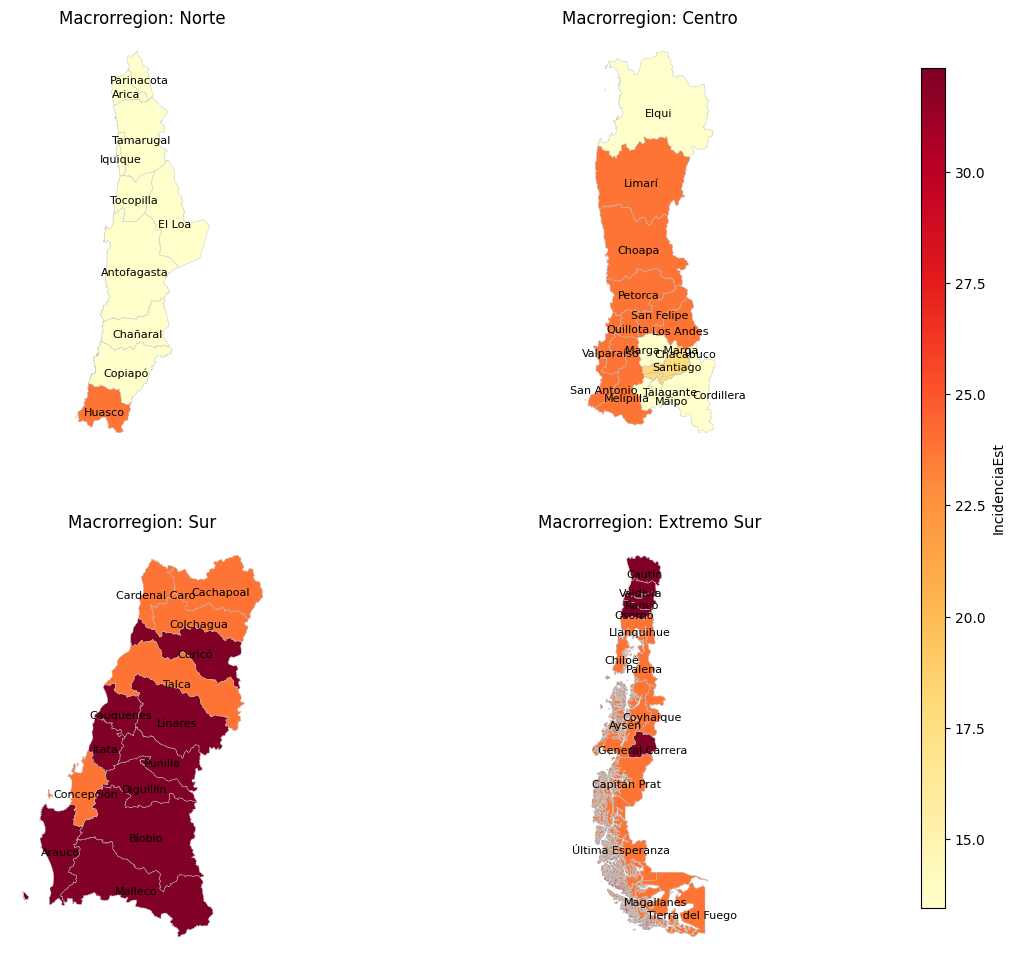

In [30]:
#@title 🌎Fig 5: Clusters

mapa_incidencia(agregar_dimensiones_mapas(calcular_incidencia_provincias(inc.copy(), niveles=['Provincia']).
                                          drop(columns='IncidenciaEst'),
                                          clusters),
                prov_gpd,
                colorDim='IncidenciaEst',
                colorScale='YlOrRd',
                subplot_col='Macrorregion',
                nombres_provincias=True,
                grilla2x2=True)

### Comparacion periodos

In [31]:
def data_clusters_periodos(incidencia_clusters=True):

  # Cargar estimaciones de incidencia
  df = calcular_incidencia_provincias(inc.copy(), niveles=['Provincia'])
  df.Periodo = df.Periodo.astype(int)

  if not incidencia_clusters:
    return df[lambda x: x.Periodo.isin([2004,2023])][['Periodo','Provincia','IncidenciaEst']]

  # Calcular incidencia por cluster-periodo
  inc_clusters = (df.
                  merge(clusters[['Provincia','Cluster']], on='Provincia').
                  groupby(['Periodo','Cluster'])[['Casos','Poblacion']].sum().reset_index())
  inc_clusters['IncidenciaEst'] = inc_clusters.Casos / inc_clusters.Poblacion * HABS

  # Primer y último periodo
  inc_clusters = (inc_clusters.merge(clusters[['Provincia','Cluster']], on='Cluster')
                              [lambda x: x.Periodo.isin([2004,2023])][['Periodo','Provincia','IncidenciaEst']])

  return inc_clusters

/tmp/ipykernel_3679/391328868.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make space for colorbar


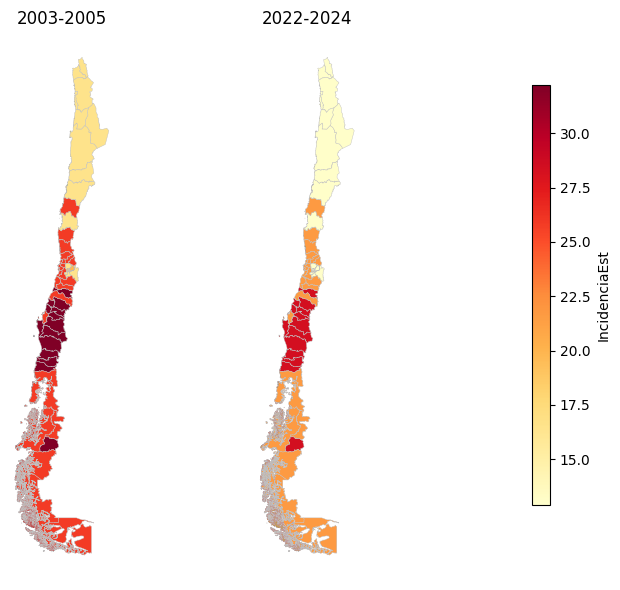

In [32]:
#@title 🌎Visual Abstract

def plot_incidence_maps_by_period(data, geo_data, color_dim='IncidenciaEst', color_scale='YlOrRd', vmax=None, nombres_provincias=False, save_path=None):

    # Merge incidence data with geographical data
    merged_data = geo_data.merge(data[data.Provincia!=52], on='Provincia', how='inner')   # Filtrar isla de pascua

    unique_periods = sorted(merged_data['Periodo'].unique())
    n_periods = len(unique_periods)
    n_cols = 3 # Aim for 3 columns per row for better readability
    n_rows = (n_periods + n_cols - 1) // n_cols

    # Generar grilla para subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 6), squeeze=False)
    axes = axes.flatten()

    # Calculate vmax and vmin across all periods for consistent color scale
    if vmax is None:
        vmax = merged_data[color_dim].max()
    vmin = merged_data[color_dim].min()

    for i, period in enumerate(unique_periods):
        ax = axes[i]
        period_data = merged_data[merged_data['Periodo'] == period]

        period_data.plot(column=color_dim, cmap=color_scale, legend=False, edgecolor='silver', linewidth=0.3, vmax=vmax, vmin=vmin, ax=ax)
        ax.set_title('2003-2005' if period==2004 else '2022-2024')
        ax.set_axis_off()

        # Add province names as text annotations if requested
        if nombres_provincias:
            for x, y, label in zip(period_data.centroid_x,
                                   period_data.centroid_y,
                                   period_data.PROVINCIA):
                ax.text(x, y, label, fontsize=6, ha='center', va='center')

    # Hide any unused subplots if n_periods is not a perfect multiple of n_cols
    for j in range(n_periods, len(axes)): fig.delaxes(axes[j])

    # Add a single colorbar for the entire figure
    cbar_ax = fig.add_axes([0.7, 0.15, 0.02, 0.7]) # [*left*, bottom, width, height]
    sm = plt.cm.ScalarMappable(cmap=color_scale, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm._A = []
    fig.colorbar(sm, cax=cbar_ax, label=color_dim)

    plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make space for colorbar
    plt.show()

    if save_path:
        fig.savefig(save_path, format='svg')


plot_incidence_maps_by_period(data_clusters_periodos(), prov_gpd, color_dim='IncidenciaEst', color_scale='YlOrRd', nombres_provincias=False)

/tmp/ipykernel_3679/391328868.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make space for colorbar


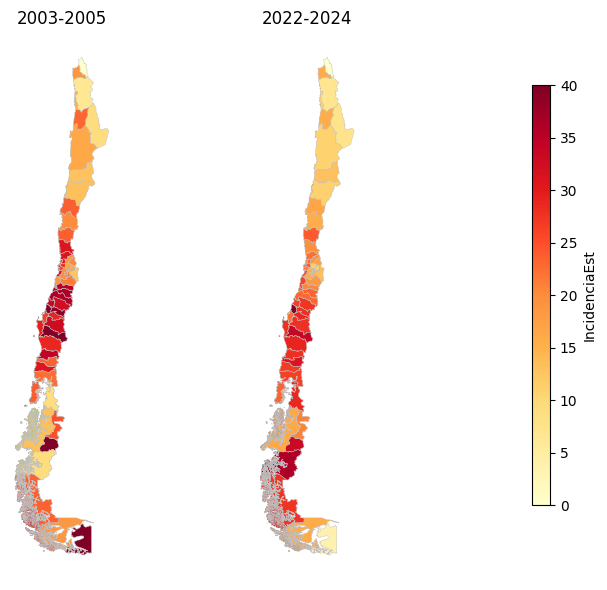

In [33]:
#@title 🌎Fig 2a
plot_incidence_maps_by_period(data_clusters_periodos(incidencia_clusters=False),
                              prov_gpd,
                              vmax=40,
                              color_dim='IncidenciaEst', color_scale='YlOrRd', nombres_provincias=False)